In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay

In [2]:
from nn import Linear, ReLU, Logistic, Tanh, Softmax, SGD, MSELoss, CrossEntropyLoss, Tensor, Sequential

## Regression

In [3]:
def f(x):
    return np.exp(-2 * x) * np.sin(6 * x)

In [4]:
X = np.random.uniform(-1., 1., (1000, 1))
Y = f(X)

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [6]:
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(Y_train)

In [7]:
X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)
Y_train = y_scaler.transform(Y_train)
Y_test = y_scaler.transform(Y_test)

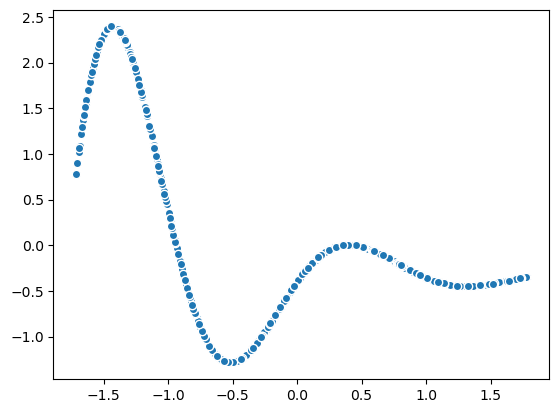

In [8]:
plt.scatter(X_train, Y_train, edgecolor="w");

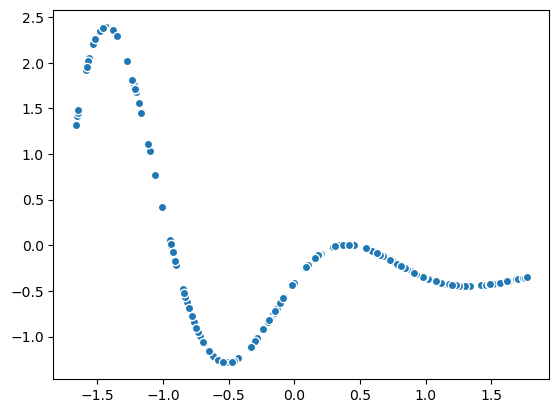

In [9]:
plt.scatter(X_test, Y_test, edgecolor="w");

In [10]:
X_train = Tensor(X_train)
X_test = Tensor(X_test)
Y_train = Tensor(Y_train)
Y_test = Tensor(Y_test)

In [11]:
model = Sequential([
    Linear(1, 8, init="xavier"),
    Tanh(),
    Linear(8, 1),
])

In [12]:
optim = SGD(model.parameters(), learning_rate=0.01)
loss = MSELoss()

In [13]:
epochs = 100000
for i in range(epochs):
    # Passe avant
    Yhat= model(X_train)
    mse = loss(Yhat, Y_train)
    # Rétro-propagation du gradient
    grad = loss.backward()
    model.backward(grad)
    # Optimisation
    optim.step()

In [14]:
Xi = np.linspace(-1, 1, 200).reshape(-1, 1)
Yi = f(Xi)
Yh = y_scaler.inverse_transform(model(Tensor(x_scaler.transform(Xi))).data)

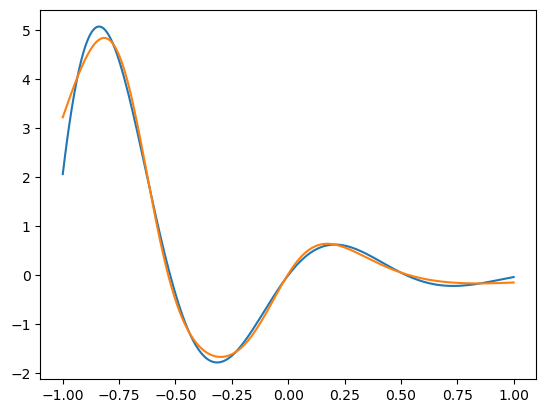

In [15]:
plt.plot(Xi, Yi);
plt.plot(Xi, Yh);

## Classification

In [324]:
n = 200
m = 3
X, Y = make_classification(n_samples=n, n_features=2, n_classes=m, n_redundant=0, n_informative=2, n_clusters_per_class=1, random_state=23)

In [325]:
onehot = np.zeros((n, m))
onehot[np.arange(n), Y] = 1.0
Y = onehot

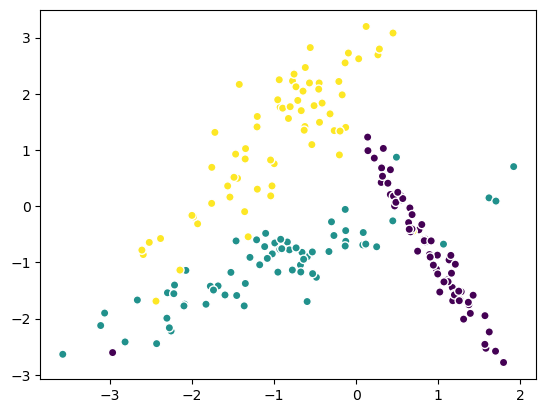

In [326]:
plt.scatter(X[:,0], X[:,1], c=Y.argmax(axis=1), edgecolor="w");

In [327]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [328]:
x_scaler = StandardScaler().fit(X_train)

In [329]:
X_train = x_scaler.transform(X_train)
X_test = x_scaler.transform(X_test)

In [330]:
X_train = Tensor(X_train)
X_test = Tensor(X_test)
Y_train = Tensor(Y_train)
Y_test = Tensor(Y_test)

In [331]:
model = Sequential([
    Linear(2, 16, init="he"),
    ReLU(),
    Linear(16, 3),
])

In [332]:
optim = SGD(model.parameters(), learning_rate=0.01)
loss = CrossEntropyLoss()

In [333]:
epochs = 100000
for i in range(epochs):
    # Passe avant
    Yhat= model(X_train)
    loss(Yhat, Y_train)
    # Rétro-propagation du gradient
    grad = loss.backward()
    model.backward(grad)
    # Optimisation
    optim.step()

In [334]:
clf = Sequential([
    model,
    Softmax()  # on rajoute le softmax pour calculer des probabilités
])

In [335]:
Yh = clf(X_test)

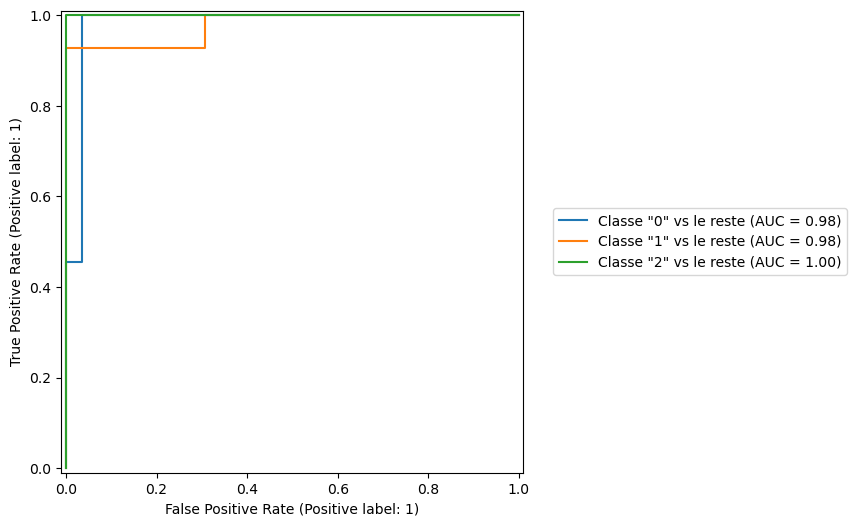

In [336]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
for i in range(3):
    RocCurveDisplay.from_predictions(y_true=Y_test.data[:,i], y_score=Yh.data[:,i], ax=ax, name=f"Classe \"{i}\" vs le reste")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5));

In [337]:
s = 50
X1, X2 = np.meshgrid(np.linspace(-4, 4, s), np.linspace(-4, 4, s))

In [338]:
Xi = x_scaler.transform(np.stack((X1.ravel(), X2.ravel())).T)

In [339]:
Yi = clf(Tensor(Xi))

In [340]:
Ci = Yi.data.argmax(axis=1).reshape((s, s))

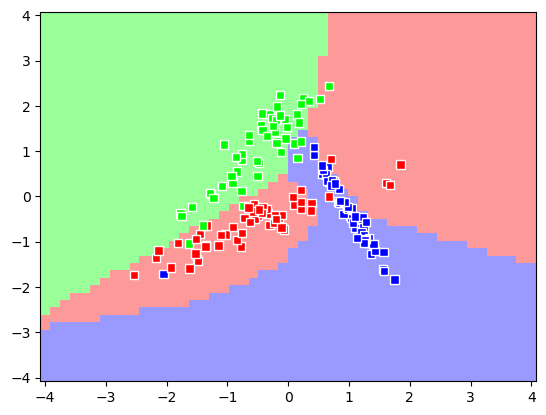

In [341]:
plt.pcolormesh(X1, X2, Ci, cmap='brg', alpha=0.4, shading='auto')
plt.scatter(X_train.data[:,0], X_train.data[:,1], c=Y_train.data.argmax(axis=1), marker="s", cmap='brg', edgecolor="w");